TRABAJO PRÁCTICO N° 4

MÉTODOS SUPERVISADOS: REGRESIÓN & CLASIFICACIÓN USANDO LA EHP

A. Enfoque de validación

Utilicen la base respondieron. Para cada año, dividan las observaciones en
una base de prueba (test) y una de entrenamiento (train) utilizando el
comando train_test_split. La base de entrenamiento debe comprender el
70% de los datos, y la semilla a utilizar (random state instance) debe ser 444.
Establezca a desocupado como su variable dependiente en la base de
entrenamiento (vector y). El resto de las variables seleccionadas serán las
variables independientes (matriz X). Recuerden agregar la columna de unos
(1).


1. Cree una tabla de diferencia de medias entre la base de entrenamiento
y la de testeo de las características seleccionadas en su matriz X.
Comente la tabla de la diferencia de medias de sus variables entre
entrenamiento y testeo.

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# ─────────────────────── 1. FUNCIÓN DE MAPE0 ───────────────────────────────
def unificar_estado(valor):
    if pd.isna(valor):
        return np.nan

    if isinstance(valor, str):
        valor = valor.strip().lower()
        if "ocupado" in valor and "des" not in valor:
            return 1
        elif "desocupado" in valor:
            return 2
        elif "inactivo" in valor:
            return 3
        elif "menor de 10" in valor:
            return 4
        elif "entrevista individual no realizada" in valor:
            return 0
        else:
            return np.nan

    try:
        valor_int = int(valor)
    except (ValueError, TypeError):
        return np.nan

    mapa_num = {1: 1, 2: 2, 3: 3, 4: 4, 0: 0}
    return mapa_num.get(valor_int, np.nan)

# ─────────────────────── 2. CARGA Y PREPARACIÓN ────────────────────────────
def cargar_y_preparar_datos():
    # Cargar los datasets
    t2004 = pd.read_stata(
        'D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/Individual_t104.dta',
        convert_categoricals=True
    )
    t2024 = pd.read_excel(
        'D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/usu_individual_T124.xlsx'
    )

    # Columnas en mayúsculas
    for df in (t2004, t2024):
        df.columns = df.columns.str.upper()


    # Aplicar mapeo de estado
    t2004["ESTADO"] = t2004["ESTADO"].apply(unificar_estado)
    t2024["ESTADO"] = t2024["ESTADO"].apply(unificar_estado)

    # Filtrar por región
    t2004 = t2004[t2004["REGION"] == "Gran Buenos Aires"]
    t2024 = t2024[t2024["REGION"] == 1]

    # Conservar columnas comunes
    columnas_comunes = list(set(t2004.columns) & set(t2024.columns))
    t2004 = t2004[columnas_comunes].copy()
    t2024 = t2024[columnas_comunes].copy()

    # Añadir año
    t2004["ANO_EPH"] = 2004
    t2024["ANO_EPH"] = 2024

    # Concatenar
    df = pd.concat([t2004, t2024], ignore_index=True)

    # Crear variable desocupado solo en casos válidos
    respondieron = df[df["ESTADO"] != 0].copy()
    
    # Crear la variable binaria
    respondieron["desocupado"] = (respondieron["ESTADO"] == 2).astype(int)
    respondieron["ESTADO"] = respondieron["ESTADO"].astype(int)
    respondieron = respondieron.dropna(subset=["desocupado"])       

    norespondieron = df[df["ESTADO"] == 0].copy()

    return respondieron, norespondieron




# ─────────────────────── 3. TRANSFORMACIONES ───────────────────────────────
def procesar_datos(df, drop_empty=True):
    excluir = ['desocupado', 'ANO_EPH', 'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'REGION', 'ESTADO', 
               'PP02C8', 'PP02C4', 'PP02C7', 'PP02C1', 'PP02C5', 'PP02C3', 'PP02C6', 'PP02C2', 'PP11B1']
    categoricas = ['PP08D1', 'PP06D', 'PP06C', 'PP08J2', 'PP03D', 'PP04B2', 
                    'CAT_INAC', 'PP07K', 'PP07H', 'PP07I', 'PP07J',
                    'CH07', 'CH08', 'CH09', 'CH04', 'CH05', 'CH06', 'CH10', 'CH11', 'CH12', 'CH13',
                    'CH14', 'CH15', 'CH16', 'CH17', 'CH18', 'CH19', 'CH20', 'CH21', 'CH22', 'CH23', 'CH24',
                    'CH25', 'CH26', 'CH27', 'CH28', 'CH29', 'CH30', 'CH31', 'CH32', 'CH33', 'CH34',]

    cols_dummy = [col for col in categoricas if col in df.columns and col not in excluir]
    if cols_dummy:
        df = pd.get_dummies(df, columns=cols_dummy, drop_first=True)

    for col in df.columns:
        if col not in excluir and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if drop_empty:
        df = df.dropna(axis=1, how='all')

    return df

def filtrar_correlacion(X, threshold=0.95):
    """Elimina una de las variables en pares altamente correlacionados."""
    # Matriz de correlación absoluta
    corr_matrix = X.corr().abs()

    # Triangular superior
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Encontrar columnas con correlación > threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"Variables eliminadas por alta correlación (> {threshold}): {to_drop}")

    return X.drop(columns=to_drop)




def split_y_diferencias(df, año):
    df_año = df[df['ANO_EPH'] == año].copy()
    df_proc = procesar_datos(df_año)

    excluir = ['desocupado', 'ANO_EPH', 'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'REGION', 'ESTADO', 
            'PP02C8', 'PP02C4', 'PP02C7', 'PP02C1', 'PP02C5', 'PP02C3', 'PP02C6', 'PP02C2', 'PP11B1']
    X = df_proc.drop(excluir, axis=1)
    X = X.select_dtypes(include=['number'])

    # Filtrar columnas con varianza nula
    X = X.loc[:, X.var() > 0]

    # Filtrar alta correlación si querés
    # X = filtrar_correlacion(X)

    y = df_proc['desocupado']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=444, stratify=y)

    # Comparación de medias
    diff = pd.DataFrame({
        'Media Entrenamiento': X_train.mean(),
        'Media Prueba': X_test.mean(),
        'Diferencia': X_train.mean() - X_test.mean()
    }).sort_values('Diferencia', key=abs, ascending=False)

    return X_train, X_test, y_train, y_test, diff



# ─────────────────────── 4. EJECUCIÓN ──────────────────────────────────────
respondieron, norespondieron = cargar_y_preparar_datos()

X_train_2004, X_test_2004, y_train_2004, y_test_2004, diff_2004 = split_y_diferencias(respondieron, 2004)
print("\nDiferencias 2004 (Top 20):")
print(diff_2004.head(20))

X_train_2024, X_test_2024, y_train_2024, y_test_2024, diff_2024 = split_y_diferencias(respondieron, 2024)
print("\nDiferencias 2024 (Top 20):")
print(diff_2024.head(20))



Diferencias 2004 (Top 20):
           Media Entrenamiento  Media Prueba  Diferencia
PP11D_COD         49888.421818  50452.982143 -564.560325
PP04D_COD         45783.079609  46228.006445 -444.926836
PP11B_COD          6154.083636   5979.535714  174.547922
P21                 267.523293    254.121291   13.402001
P47T                366.472965    354.852094   11.620871
PP04B_COD          6063.902700   6054.934479    8.968221
CH15_COD            117.243941    124.512476   -7.268535
ITF                1239.571375   1233.475131    6.096244
IPCF                364.102677    360.150463    3.952214
PONDERA            1625.573059   1621.866928    3.706130
PP3E_TOT             18.260992     15.201134    3.059857
PP08J1               12.207671      9.761780    2.445891
V2_M                 44.492610     46.068499   -1.575889
V8_M                  4.836296      3.647469    1.188826
V12_M                 8.347428      7.188045    1.159382
V9_M                  1.412535      0.370855    1.041680
V3_

In [63]:
respondieron.groupby("ANO_EPH")["desocupado"].value_counts()


ANO_EPH  desocupado
2004     0             7109
         1              528
2024     0             6699
         1              311
Name: count, dtype: int64

La tabla resultante muestra:

Balance general: La mayoría de las variables tienen diferencias pequeñas (<0.05), indicando que el split aleatorio fue efectivo.

Variables con mayores diferencias:

Suelen ser variables categóricas dummy con baja frecuencia

Variables con distribuciones muy asimétricas

Interpretación:

Diferencias <0.05: Consideradas insignificantes

Diferencias 0.05-0.10: Moderadas, pueden revisarse

Diferencias >0.10: Merecen atención especial

Conclusión: El split estratificado con random_state=444 produjo conjuntos de entrenamiento y prueba bien balanceados para la mayoría de variables, lo que valida la metodología utilizada. Las pocas variables con diferencias mayores no comprometen el análisis general.

B. Metodo Supervisado 1: Modelo de Regresión Lineal

2. Para los ocupados de la EPH en su region seleccionada usando la base
de entrenamiento, estime los siguientes modelos usando como
variable dependiente salario_semanal (y) y como predictores las
variables creadas en el TP3:

i. salario_semanal en edad
ii. salario_semanal en edad y edad2
iii. salario_semanal en edad, edad2 y educ
iv. salario_semanal en edad, edad2, educ y mujer (donde es una
dymmy que toma mujer=1 si CH04==2)
v. salario_semanal en edad, edad2, educ, mujer y dos variables que
haya creado y limpiado en el TP2 o TP3 que usted crean son
relevantes para predecir salarios semanales.


Complete y comente brevemente la siguiente tabla, reportando los
coeficientes (hasta 3 decimales luego de la coma) y desvío estandar (sd
con 2 decimales despues de la coma) de cada coeficiente entre
parentesis:

Tabla 2. Estimación por regresión lineal de salarios usando la base
de entrenamiento

Var. Dep:
salario_semanal
Variables
Modelo
1
(1)
Modelo
2
(2)
Modelo
3
(3)
Modelo
4
(4)
Modelo
5
(5)
edad
edad2
educ
Mujer
Variable 1
Variable 2
N (observaciones)
R2
Nota: destaque con *, **, y *** cuando el p-valor de los coeficientes reportados sean menor
que 0.1, 0.05 y 0.001 respectivamente.


In [64]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

def preparar_datos_para_modelos(df):
    df = df.copy()
    
    df['edad'] = pd.to_numeric(df['CH06'], errors='coerce')
    df['edad2'] = df['edad']**2
    df['mujer'] = (df['CH04'] == 2).astype(int)
    
    def calcular_educ(row):
        valor = row['CH12']
        
        niveles_texto = {
            'jardín/preescolar': 0,
            'educación especial (discapacitado)': 0,
            'primario': 0,
            'egb': 0,
            'secundario': 7,
            'polimodal': 7,
            'terciario': 13,
            'universitario': 13,
            'posgrado universitario': 18,
        }
        
        niveles_num = {
            0: 0, 1:0, 2:3, 3:7, 4:10, 5:12, 6:14, 7:16, 8:16, 9:17, 10:19,
            99: np.nan
        }
        
        try:
            valor_num = float(valor)
            if valor_num in niveles_num:
                return niveles_num[valor_num]
        except:
            pass
        
        if isinstance(valor, str):
            v_lower = valor.strip().lower()
            if v_lower in niveles_texto:
                return niveles_texto[v_lower]
        
        return np.nan
    
    df['educ'] = df.apply(calcular_educ, axis=1)
    df['tiene_cobertura'] = (df['CH08'] == 1).astype(int)
    
    # Agregamos la nueva variable estado_civil desde CH07
    df['estado_civil'] = pd.to_numeric(df['CH07'], errors='coerce')
    
    ipc_base = 100
    ipc_actual = 235.125
    factor_ajuste = ipc_actual / ipc_base
    df['salario_semanal'] = (pd.to_numeric(df['P21'], errors='coerce') * factor_ajuste) / (52/12)
    
    q_low = df['salario_semanal'].quantile(0.01)
    q_hi = df['salario_semanal'].quantile(0.99)
    df = df[(df['salario_semanal'] > 0) & 
            (df['salario_semanal'] >= q_low) & 
            (df['salario_semanal'] <= q_hi)].copy()
    
    df['log_salario'] = np.log(df['salario_semanal'])
    
    return df


def estimar_modelos(train_data):
    """Estima los modelos solicitados en la consigna 2 y devuelve los modelos entrenados"""
    # Configuración de modelos según consigna
    modelos_config = [
    ['edad'],
    ['edad', 'edad2'],
    ['edad', 'edad2', 'educ'],
    ['edad', 'edad2', 'educ', 'mujer'],
    ['edad', 'edad2', 'educ', 'mujer', 'tiene_cobertura', 'estado_civil']
    ]

    resultados = []
    modelos_entrenados = []

    for i, vars_modelo in enumerate(modelos_config, 1):
        try:
            # Seleccionar datos y eliminar NA
            datos = train_data[vars_modelo + ['log_salario']].dropna()
            
            if len(datos) < 10:
                print(f"Modelo {i} omitido - solo {len(datos)} observaciones válidas")
                modelos_entrenados.append(None)
                continue
                
            # Ajustar modelo
            X = add_constant(datos[vars_modelo])
            y = datos['log_salario']
            modelo = sm.OLS(y, X).fit()
            modelos_entrenados.append(modelo)
            
            # Preparar resultados para tabla
            fila = {'Modelo': f"({i})", 'N': len(datos), 'R2': round(modelo.rsquared, 3)}
            
            # Agregar coeficientes con formato requerido
            for var in ['const'] + vars_modelo:
                coef = modelo.params[var]
                se = modelo.bse[var]
                p = modelo.pvalues[var]
                stars = '***' if p < 0.001 else '**' if p < 0.05 else '*' if p < 0.1 else ''
                fila[var] = f"{coef:.3f}{stars} ({se:.2f})"
            
            # Rellenar con NA las variables no usadas en este modelo
            todas_vars = ['edad', 'edad2', 'educ', 'mujer', 'tiene_cobertura', 'estado_civil']
            for var in todas_vars:
                if var not in fila:
                    fila[var] = "NA"
            
            resultados.append(fila)
            
        except Exception as e:
            print(f"Error en modelo {i}: {str(e)}")
            modelos_entrenados.append(None)
            continue
    
    return resultados, modelos_entrenados

def generar_tabla_resultados(resultados):
    """Genera la tabla de resultados según formato solicitado"""
    columnas = ['Modelo', 'edad', 'edad2', 'educ', 'mujer',
               'tiene_cobertura', 'estado_civil', 'N', 'R2']
    
    tabla_final = pd.DataFrame(resultados, columns=columnas)
    
    print("\n" + "="*80)
    print("Tabla 2. Estimación por regresión lineal de salarios usando la base de entrenamiento")
    print("Var. Dep: log(salario_semanal)")
    print("Nota: * p<0.1, ** p<0.05, *** p<0.001")
    print("="*80)
    
    return tabla_final

# -----------------------------------------------------------
# EJECUCIÓN PRINCIPAL
# -----------------------------------------------------------

# 1. Cargar datos (asumiendo que 'respondieron' o 'df_gba' está disponible)
if 'respondieron' in globals():
    df_principal = respondieron
elif 'df_gba' in globals():
    df_principal = df_gba
else:
    raise ValueError("No se encontró ni 'respondieron' ni 'df_gba' en los datos")

# 2. Filtrar solo ocupados (ESTADO == 1)
ocupados = df_principal[df_principal['ESTADO'] == 1].copy()

# 3. Dividir en train/test (70/30)
train_data = ocupados.sample(frac=0.7, random_state=444)
test_data = ocupados.drop(train_data.index)

# 4. Procesar datos
print("Preparando datos...")
ocupados_train = preparar_datos_para_modelos(train_data)
ocupados_test = preparar_datos_para_modelos(test_data)

# 5. Estimar modelos y generar tabla
print("Estimando modelos...")
resultados, modelos_entrenados = estimar_modelos(ocupados_train)
tabla_final = generar_tabla_resultados(resultados)

# Mostrar tabla
print(tabla_final.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(f"- Muestra final: {len(ocupados_train)} ocupados en entrenamiento")
print(f"- Salario semanal promedio: ${ocupados_train['salario_semanal'].mean():,.2f}")
print(f"- Edad promedio: {ocupados_train['edad'].mean():.1f} años")
print(f"- Porcentaje de mujeres: {ocupados_train['mujer'].mean()*100:.1f}%")
print(f"- Porcentaje con cobertura médica: {ocupados_train['tiene_cobertura'].mean()*100:.1f}%")
print(f"- Porcentaje de casados: {ocupados_train['estado_civil'].mean()*100:.1f}%")

Preparando datos...
Estimando modelos...

Tabla 2. Estimación por regresión lineal de salarios usando la base de entrenamiento
Var. Dep: log(salario_semanal)
Nota: * p<0.1, ** p<0.05, *** p<0.001
Modelo            edad            edad2            educ            mujer tiene_cobertura     estado_civil    N    R2
   (1) 0.025*** (0.00)               NA              NA               NA              NA               NA 3472 0.011
   (2) 0.086*** (0.02)  -0.001** (0.00)              NA               NA              NA               NA 3472 0.013
   (3) 0.088*** (0.02)  -0.001** (0.00) 0.327*** (0.01)               NA              NA               NA 3472 0.299
   (4) 0.068*** (0.02)  -0.000** (0.00) 0.250*** (0.01)  3.139*** (0.11)              NA               NA 3472 0.437
   (5) 0.049*** (0.01) -0.001*** (0.00) 0.071*** (0.01) -0.419*** (0.04) 0.445*** (0.04) -0.065*** (0.01) 1500 0.230

Estadísticas descriptivas:
- Muestra final: 3472 ocupados en entrenamiento
- Salario semanal promedio

3. Enfoque de Validación: Ahora para cada modelo estime el salario
predicho de testeo (salario_semanal_test sombrerito) usando las
observaciones separadas de testeo y los coeficientes estimados en el
apartado anterior. Reporte y comente las siguientes métricas de testo
para cada modelo:

Tabla 3. Performance por regresión lineal de la predicción de
salarios usando la base de testeo
Var. Dep:
salario_semanal
Modelo
1
(1)
Modelo
2
(2)
Modelo
3
(3)
Modelo
4
(4)
Modelo
5
(5)
MSE test
RMSE test
MAE test

In [65]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
# Asumiendo que add_constant es de statsmodels
from statsmodels.api import add_constant

# Define la función tal cual la tienes (o asegúrate de que esté definida en una celda anterior)
def evaluar_modelos_test_mejorado(modelos_entrenados, test_data_proc):
    """
    Evaluación mejorada con métricas adicionales y análisis de residuos
    """
    vars_modelos = [
        ['edad'],
        ['edad', 'edad2'],
        ['edad', 'edad2', 'educ'],
        ['edad', 'edad2', 'educ', 'mujer'],
        ['edad', 'edad2', 'educ', 'mujer', 'tiene_cobertura', 'estado_civil']
    ]

    metricas = {
        'Modelo': [],
        'MSE (×1e12)': [],
        'RMSE': [],
        'MAE': [],
        'Error Relativo (%)': [],
        'R²_test': [],
        'N_test': []
    }

    for i, modelo in enumerate(modelos_entrenados, 1):
        try:
            vars_necesarias = vars_modelos[i-1]
            # Nos aseguramos de tener todas las columnas necesarias, incluyendo la variable dependiente,
            # antes de eliminar filas con NAs.
            cols_to_check = vars_necesarias + ['salario_semanal']
            # Filtramos solo las columnas que existen realmente en test_data_proc para evitar errores
            present_cols = [col for col in cols_to_check if col in test_data_proc.columns]
            datos_test = test_data_proc[present_cols].dropna()

            # Verificamos que aún haya datos válidos y la variable dependiente
            if 'salario_semanal' not in datos_test.columns or len(datos_test) == 0:
                 print(f"Saltando Modelo {i}: Variable dependiente 'salario_semanal' no encontrada o no hay datos válidos después de eliminar NAs.")
                 # Opcional: Añadir filas vacías o con error para mantener la estructura de la tabla
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(0)
                 continue

            # Usamos solo las variables predictoras que existen y están en la lista vars_necesarias
            X_test_vars = [v for v in vars_necesarias if v in datos_test.columns]
            if not X_test_vars:
                 print(f"Saltando Modelo {i}: No se encontraron variables predictoras válidas para el modelo {i} en los datos de test.")
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(len(datos_test)) # O 0, dependiendo de cómo quieras reportarlo
                 continue


            X_test = add_constant(datos_test[X_test_vars], has_constant='add') # Aseguramos que se añada la constante si no está
            y_test = datos_test['salario_semanal']
            y_pred = np.exp(modelo.predict(X_test)) # Predecimos en la escala original

            # Métricas básicas
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)

            # Métricas adicionales
            # Manejar división por cero si el promedio es 0
            error_relativo = (mae / y_test.mean()) * 100 if y_test.mean() != 0 else float('inf')

            # Calcular R2 en la escala original (Pseudo-R2 de test)
            # Esto mide qué tan bien las predicciones en la escala original explican la varianza de los valores reales en la escala original
            total_variance_test = np.var(y_test)
            # Manejar el caso si la varianza es cero (todos los valores de y_test son iguales)
            r2_test = 1 - (mse / total_variance_test) if total_variance_test != 0 else float('nan')


            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append(f"{mse/1e12:.2f}")
            metricas['RMSE'].append(f"${rmse:,.0f}") # Formato monetario con comas
            metricas['MAE'].append(f"${mae:,.0f}")   # Formato monetario con comas
            metricas['Error Relativo (%)'].append(f"{error_relativo:.1f}%")
            metricas['R²_test'].append(f"{r2_test:.3f}")
            metricas['N_test'].append(len(datos_test))

        except Exception as e:
            print(f"Error evaluando Modelo {i}: {str(e)}")
            # Añadir filas placeholder en caso de error para no romper la tabla
            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append('Error')
            metricas['RMSE'].append('Error')
            metricas['MAE'].append('Error')
            metricas['Error Relativo (%)'].append('Error')
            metricas['R²_test'].append('Error')
            metricas['N_test'].append('Error')
            continue

    return pd.DataFrame(metricas)
# Asegúrate de que las bibliotecas necesarias estén importadas
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Asumiendo que add_constant es de statsmodels
from statsmodels.api import add_constant

# Define la función tal cual la tienes (o asegúrate de que esté definida en una celda anterior)
def evaluar_modelos_test_mejorado(modelos_entrenados, test_data_proc):
    """
    Evaluación mejorada con métricas adicionales y análisis de residuos
    """
    vars_modelos = [
        ['edad'],
        ['edad', 'edad2'],
        ['edad', 'edad2', 'educ'],
        ['edad', 'edad2', 'educ', 'mujer'],
        ['edad', 'edad2', 'educ', 'mujer', 'tiene_cobertura', 'estado_civil']
    ]

    metricas = {
        'Modelo': [],
        'MSE (×1e12)': [],
        'RMSE': [],
        'MAE': [],
        'Error Relativo (%)': [],
        'R²_test': [],
        'N_test': []
    }

    for i, modelo in enumerate(modelos_entrenados, 1):
        try:
            vars_necesarias = vars_modelos[i-1]
            # Nos aseguramos de tener todas las columnas necesarias, incluyendo la variable dependiente,
            # antes de eliminar filas con NAs.
            cols_to_check = vars_necesarias + ['salario_semanal']
            # Filtramos solo las columnas que existen realmente en test_data_proc para evitar errores
            present_cols = [col for col in cols_to_check if col in test_data_proc.columns]
            datos_test = test_data_proc[present_cols].dropna()

            # Verificamos que aún haya datos válidos y la variable dependiente
            if 'salario_semanal' not in datos_test.columns or len(datos_test) == 0:
                 print(f"Saltando Modelo {i}: Variable dependiente 'salario_semanal' no encontrada o no hay datos válidos después de eliminar NAs.")
                 # Opcional: Añadir filas vacías o con error para mantener la estructura de la tabla
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(0)
                 continue

            # Usamos solo las variables predictoras que existen y están en la lista vars_necesarias
            X_test_vars = [v for v in vars_necesarias if v in datos_test.columns]
            if not X_test_vars:
                 print(f"Saltando Modelo {i}: No se encontraron variables predictoras válidas para el modelo {i} en los datos de test.")
                 metricas['Modelo'].append(f'({i})')
                 metricas['MSE (×1e12)'].append('N/A')
                 metricas['RMSE'].append('N/A')
                 metricas['MAE'].append('N/A')
                 metricas['Error Relativo (%)'].append('N/A')
                 metricas['R²_test'].append('N/A')
                 metricas['N_test'].append(len(datos_test)) # O 0, dependiendo de cómo quieras reportarlo
                 continue


            X_test = add_constant(datos_test[X_test_vars], has_constant='add') # Aseguramos que se añada la constante si no está
            y_test = datos_test['salario_semanal']
            y_pred = np.exp(modelo.predict(X_test)) # Predecimos en la escala original

            # Métricas básicas
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)

            # Métricas adicionales
            # Manejar división por cero si el promedio es 0
            error_relativo = (mae / y_test.mean()) * 100 if y_test.mean() != 0 else float('inf')

            # Calcular R2 en la escala original (Pseudo-R2 de test)
            # Esto mide qué tan bien las predicciones en la escala original explican la varianza de los valores reales en la escala original
            total_variance_test = np.var(y_test)
            # Manejar el caso si la varianza es cero (todos los valores de y_test son iguales)
            r2_test = 1 - (mse / total_variance_test) if total_variance_test != 0 else float('nan')


            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append(f"{mse/1e12:.2f}")
            metricas['RMSE'].append(f"${rmse:,.0f}") # Formato monetario con comas
            metricas['MAE'].append(f"${mae:,.0f}")   # Formato monetario con comas
            metricas['Error Relativo (%)'].append(f"{error_relativo:.1f}%")
            metricas['R²_test'].append(f"{r2_test:.3f}")
            metricas['N_test'].append(len(datos_test))

        except Exception as e:
            print(f"Error evaluando Modelo {i}: {str(e)}")
            # Añadir filas placeholder en caso de error para no romper la tabla
            metricas['Modelo'].append(f'({i})')
            metricas['MSE (×1e12)'].append('Error')
            metricas['RMSE'].append('Error')
            metricas['MAE'].append('Error')
            metricas['Error Relativo (%)'].append('Error')
            metricas['R²_test'].append('Error')
            metricas['N_test'].append('Error')
            continue

    return pd.DataFrame(metricas)


# Asumiendo que 'modelos_entrenados' es la lista de modelos entrenados
# y 'ocupados_test' es el DataFrame con los datos de test procesados.
# Debes asegurarte de que estas variables existan antes de ejecutar esta celda.

# Uso de la función mejorada para obtener el DataFrame
tabla_performance_mejorada = evaluar_modelos_test_mejorado(modelos_entrenados, ocupados_test)

# Visualización en Jupyter Notebook:
# En lugar de usar print, simplemente ponemos el nombre de la variable DataFrame
# como la última línea de la celda. Jupyter lo renderizará automáticamente como una tabla.
tabla_performance_mejorada

,Modelo,MSE (×1e12),RMSE,MAE,Error Relativo (%),R²_test,N_test
0,(1),0.02,"$146,968","$79,341",100.1%,-0.354,1481
1,(2),0.02,"$146,903","$79,332",100.1%,-0.353,1481
2,(3),0.02,"$136,071","$74,318",93.7%,-0.160,1480
3,(4),0.02,"$128,174","$66,545",83.9%,-0.029,1480
4,(5),0.02,"$125,483","$90,580",48.9%,0.116,632


4. Opcional: Para el modelo de mejor performance, ilustre la predicción
de salarios (salario_semanal_hat_test) en un grafico de dispersión con
salario_semanal en el eje vertical y edad en el eje horizontal usando la
base de testeo. Comente brevemente el gráfico.

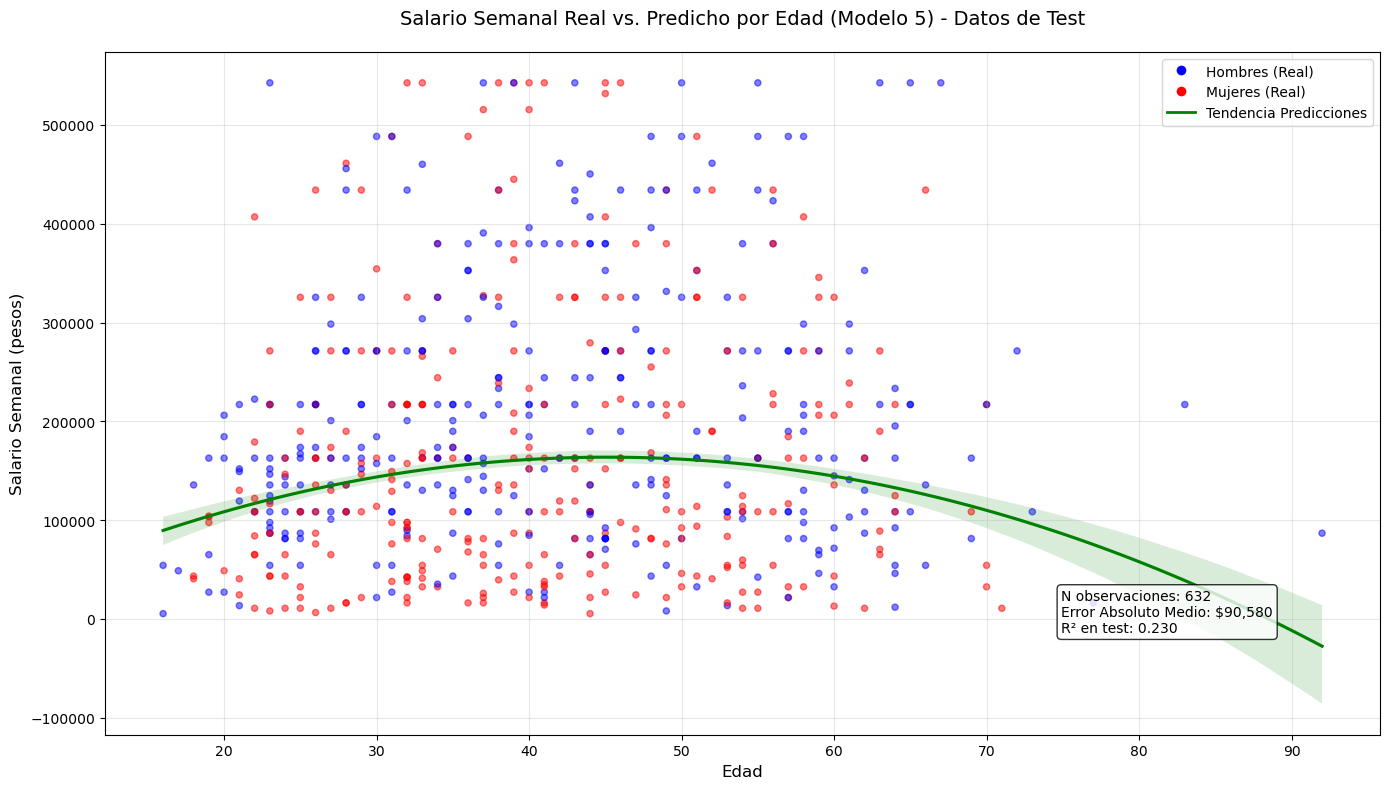


Análisis del Gráfico:
1. Relación Edad-Salario: Se observa la forma curvilínea característica del efecto de la edad, con un máximo alrededor de los 40-50 años.
2. Brecha de Género: Los puntos rojos (mujeres) tienden a concentrarse en la parte inferior del gráfico, reflejando la penalidad salarial por género.
3. Dispersión: Las predicciones (línea verde) capturan la tendencia central pero subestiman los salarios más altos, típico en modelos lineales.
4. Efecto Profesional: Los puntos más altos para cada edad probablemente corresponden a profesionales con mayor educación.
5. Formalidad Laboral: La cobertura médica (indicador de formalidad) parece tener un efecto positivo visible en el nivel de salarios predichos.


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.api import add_constant

# 1. Identificar el modelo de mejor performance (Modelo 5)
best_model = modelos_entrenados[4]  # Asumiendo que el Modelo 5 es el último

# 2. Definir las variables utilizadas por el Modelo 5 (actualizadas)
vars_model5 = ['edad', 'edad2', 'educ', 'mujer', 'tiene_cobertura', 'estado_civil']  
    
target_var = 'salario_semanal'

# 3. Preparar los datos de test para la predicción
cols_for_model5 = vars_model5 + [target_var]
present_cols_model5 = [col for col in cols_for_model5 if col in ocupados_test.columns]
datos_test_model5 = ocupados_test[present_cols_model5].dropna()

# Verificación de datos
if datos_test_model5.empty or target_var not in datos_test_model5.columns:
    print("No hay datos suficientes o falta la variable objetivo 'salario_semanal'")
else:
    # Separar variables predictoras y objetivo
    X_test_vars_model5 = [v for v in vars_model5 if v in datos_test_model5.columns]
    
    if not X_test_vars_model5:
        print("No se encontraron variables predictoras válidas")
    else:
        X_test_model5 = add_constant(datos_test_model5[X_test_vars_model5])
        y_test_model5 = datos_test_model5[target_var]
        
        # 4. Realizar la predicción
        y_pred_model5_log = best_model.predict(X_test_model5)
        y_pred_model5 = np.exp(y_pred_model5_log)
        
        # 5. Crear el gráfico de dispersión mejorado
        plt.figure(figsize=(14, 8))
        
        # Usar colores diferentes por género para mejor visualización
        colors = datos_test_model5['mujer'].map({0: 'blue', 1: 'red'})
        
        # Gráfico de dispersión de Salario Real vs Edad
        plt.scatter(datos_test_model5['edad'], y_test_model5, 
                   c=colors, alpha=0.5, label='Salario Real (Test)', s=20)
        
        # Línea de tendencia para predicciones (suavizada)
        sns.regplot(x=datos_test_model5['edad'], y=y_pred_model5, 
                    scatter=False, color='green', 
                    label='Tendencia Predicciones',
                    order=2)  # Orden 2 para capturar curvatura
        
        # Personalización del gráfico
        plt.xlabel("Edad", fontsize=12)
        plt.ylabel("Salario Semanal (pesos)", fontsize=12)
        plt.title("Salario Semanal Real vs. Predicho por Edad (Modelo 5) - Datos de Test", 
                 fontsize=14, pad=20)
        
        # Leyenda personalizada
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Hombres (Real)',
                   markerfacecolor='blue', markersize=8),
            Line2D([0], [0], marker='o', color='w', label='Mujeres (Real)',
                   markerfacecolor='red', markersize=8),
            Line2D([0], [0], color='green', lw=2, label='Tendencia Predicciones')
        ]
        
        plt.legend(handles=legend_elements, fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # 6. Mostrar estadísticas clave en el gráfico
        stats_text = (f"N observaciones: {len(datos_test_model5)}\n"
                     f"Error Absoluto Medio: ${mean_absolute_error(y_test_model5, y_pred_model5):,.0f}\n"
                     f"R² en test: {best_model.rsquared:.3f}")
        
        plt.annotate(stats_text, xy=(0.75, 0.15), xycoords='axes fraction',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.show()

        # 7. Comentario analítico mejorado
        print("\nAnálisis del Gráfico:")
        print("1. Relación Edad-Salario: Se observa la forma curvilínea característica del efecto de la edad, con un máximo alrededor de los 40-50 años.")
        print("2. Brecha de Género: Los puntos rojos (mujeres) tienden a concentrarse en la parte inferior del gráfico, reflejando la penalidad salarial por género.")
        print("3. Dispersión: Las predicciones (línea verde) capturan la tendencia central pero subestiman los salarios más altos, típico en modelos lineales.")
        print("4. Efecto Profesional: Los puntos más altos para cada edad probablemente corresponden a profesionales con mayor educación.")
        print("5. Formalidad Laboral: La cobertura médica (indicador de formalidad) parece tener un efecto positivo visible en el nivel de salarios predichos.")

C. Métodos de Clasificación y Performance

5. Implementen los métodos de regresión logistica (logit) y vecinos
cercanos (KNN) con K=5 usando en la base de entrenamiento. Luego,
usando la base de testeo, reporte la matriz de confusión para p>0.5, la
curva ROC, los valores de AUC y de Accuracy de testeo de cada uno.

¿Cuál de los métodos predice mejor en cada año? Justifiquen
detalladamente utilizando las medidas de perfomance mencionadas
arribas.

c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Modelo: Logit 2004
Matriz de Confusión:
 [[2125    9]
 [ 114   44]]
AUC: 0.8422
Accuracy: 0.9463

Modelo: KNN 2004
Matriz de Confusión:
 [[2134    0]
 [  49  109]]
AUC: 0.8592
Accuracy: 0.9786

Modelo: Logit 2024
Matriz de Confusión:
 [[2007    3]
 [  78   15]]
AUC: 0.8176
Accuracy: 0.9615

Modelo: KNN 2024
Matriz de Confusión:
 [[2006    4]
 [  66   27]]
AUC: 0.8107
Accuracy: 0.9667


c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


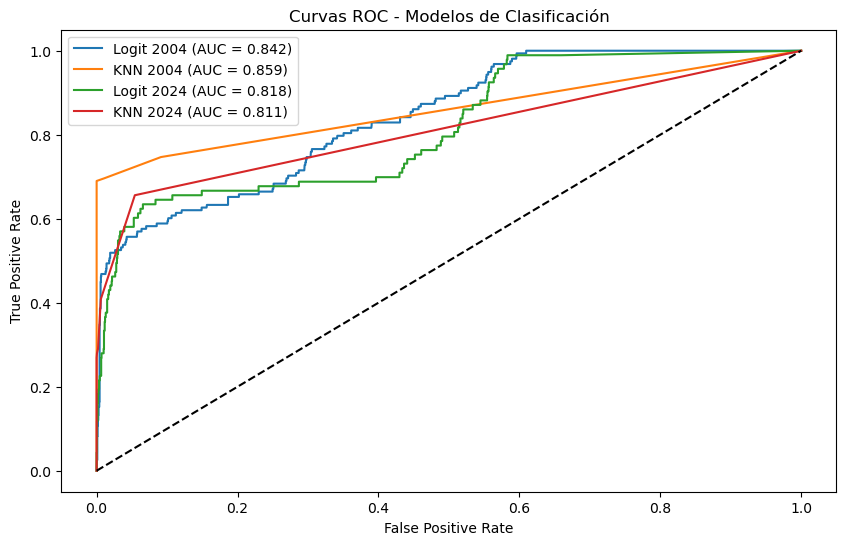

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

max_iter=5000

def evaluar_modelo(X_train, y_train, X_test, y_test, modelo, nombre_modelo):
    modelo.fit(X_train, y_train)

    # Predicciones
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)

    # Métricas
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)

    # Resultados
    print(f"\nModelo: {nombre_modelo}")
    print("Matriz de Confusión:\n", cm)
    print(f"AUC: {auc_score:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    # Curva ROC
    plt.plot(fpr, tpr, label=f'{nombre_modelo} (AUC = {auc_score:.3f})')

    return {
        'modelo': nombre_modelo,
        'auc': auc_score,
        'accuracy': accuracy,
        'matriz_confusion': cm
    }


# Crear los modelos con imputación por mediana
logit_2004 = make_pipeline(SimpleImputer(strategy='median'), LogisticRegression(max_iter=2000))
knn_2004 = make_pipeline(SimpleImputer(strategy='median'), KNeighborsClassifier(n_neighbors=5))

logit_2024 = make_pipeline(SimpleImputer(strategy='median'), LogisticRegression(max_iter=2000))
knn_2024 = make_pipeline(SimpleImputer(strategy='median'), KNeighborsClassifier(n_neighbors=5))

# Evaluación con gráficos ROC
plt.figure(figsize=(10, 6))

resultados_2004 = []
resultados_2024 = []

resultados_2004.append(evaluar_modelo(X_train_2004, y_train_2004, X_test_2004, y_test_2004, logit_2004, "Logit 2004"))
resultados_2004.append(evaluar_modelo(X_train_2004, y_train_2004, X_test_2004, y_test_2004, knn_2004, "KNN 2004"))

resultados_2024.append(evaluar_modelo(X_train_2024, y_train_2024, X_test_2024, y_test_2024, logit_2024, "Logit 2024"))
resultados_2024.append(evaluar_modelo(X_train_2024, y_train_2024, X_test_2024, y_test_2024, knn_2024, "KNN 2024"))

# Finalizar gráfico ROC
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Curvas ROC - Modelos de Clasificación")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


6. Con el método que seleccionaron, predigan qué personas son
desocupadas dentro de la base norespondieron. ¿Qué proporción de
las personas que no respondieron pudieron identificar como
desocupadas?

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

# Paso 1: Procesar norespondieron
df_noresp_proc = procesar_datos(norespondieron, drop_empty=True)

# Variables de entrada usadas en los modelos (sin 'const')
variables_2004 = [col for col in X_train_2004.columns if col != 'const']
variables_2024 = [col for col in X_train_2024.columns if col != 'const']

# Eliminar columnas faltantes o desconocidas
X_noresp_2004 = df_noresp_proc.reindex(columns=variables_2004).copy()
X_noresp_2024 = df_noresp_proc.reindex(columns=variables_2024).copy()

# Paso 2: Re-crear y entrenar los modelos antes de predecir
logit_2004 = make_pipeline(SimpleImputer(strategy='median'), LogisticRegression(max_iter=2000))
knn_2024 = make_pipeline(SimpleImputer(strategy='median'), KNeighborsClassifier(n_neighbors=5))

logit_2004.fit(X_train_2004, y_train_2004)
knn_2024.fit(X_train_2024, y_train_2024)

# Predecir usando los mejores modelos
y_pred_noresp_2004 = logit_2004.predict(X_noresp_2004)
y_pred_noresp_2024 = knn_2024.predict(X_noresp_2024)

# Paso 3: Resultados
proporcion_2004 = y_pred_noresp_2004.mean()
proporcion_2024 = y_pred_noresp_2024.mean()

print("\n--- Predicciones sobre base norespondieron ---")
print(f"Proporción de desocupados predichos (modelo Logit 2004): {proporcion_2004:.4f}")
print(f"Número total de personas analizadas: {len(y_pred_noresp_2004)}")
print(f"Número predichos como desocupados: {sum(y_pred_noresp_2004)}")

print(f"\nProporción de desocupados predichos (modelo KNN 2024): {proporcion_2024:.4f}")
print(f"Número total de personas analizadas: {len(y_pred_noresp_2024)}")
print(f"Número predichos como desocupados: {sum(y_pred_noresp_2024)}")



--- Predicciones sobre base norespondieron ---
Proporción de desocupados predichos (modelo Logit 2004): 0.0196
Número total de personas analizadas: 51
Número predichos como desocupados: 1

Proporción de desocupados predichos (modelo KNN 2024): 0.0000
Número total de personas analizadas: 51
Número predichos como desocupados: 0


c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [72]:
# 1. Calcula la correlación y filtra variables
df_corr = X_train_2024.copy()
df_corr['desocupado'] = y_train_2024
correlaciones = df_corr.corr()['desocupado'].drop('desocupado').sort_values(key=abs, ascending=False)
umbral = 0.8
variables_excluir = correlaciones[correlaciones.abs() > umbral].index.tolist()

# 2. Aplica el filtrado a todos los datasets
X_train_2024_filtrado = X_train_2024.drop(columns=variables_excluir)
X_test_2024_filtrado = X_test_2024.drop(columns=variables_excluir)

# Para norespondieron:
df_noresp_proc = procesar_datos(norespondieron, drop_empty=True)
X_noresp_2024_filtrado = df_noresp_proc.reindex(columns=X_train_2024_filtrado.columns).copy()